In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import sklearn
import math
import statisticstemp_data['revol_util'] = temp_data['revol_util'].str.rstrip('%').astype(float)
import warnings
warnings.filterwarnings(action='ignore')
pd.options.display.float_format = '{:.5f}'.format
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)


pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)

In [7]:
temp_data=pd.read_csv('lending_club_2020_train.csv',low_memory=False)

In [8]:
temp_data['revol_util'] = temp_data['revol_util'].str.rstrip('%').astype(float)
temp_data = temp_data[temp_data['revol_util'] <= 200]

In [9]:
temp_data[temp_data['revol_util']>200]

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag


In [12]:
# 두 컬럼의 상관계수를 계산합니다.
correlation = temp_data['funded_amnt'].corr(temp_data['funded_amnt_inv'])

# 결과 출력
print("funded_amnt와 funded_amnt_inv의 상관계수:", correlation)


funded_amnt와 funded_amnt_inv의 상관계수: 0.9995070302184835


In [19]:
temp_data[temp_data['funded_amnt']>temp_data['funded_amnt_inv']+5000]['grade'].value_counts()

grade
C    322
B    257
D    214
E    162
F     79
A     67
G     49
Name: count, dtype: int64

In [10]:
temp_data[['funded_amnt','funded_amnt_inv']].head(30)

,funded_amnt,funded_amnt_inv
0,6000.00000,6000.00000
1,35000.00000,35000.00000
2,23200.00000,23200.00000
3,4500.00000,4500.00000
4,15000.00000,15000.00000
5,16000.00000,16000.00000
6,4500.00000,4500.00000
7,20000.00000,20000.00000
8,19000.00000,18999.73994
9,35000.00000,35000.00000


In [ ]:
df=pd.read_csv('lending_club_2020_train.csv',low_memory=False)

In [4]:
temp_list='''
sec_app_mort_acc
sec_app_open_acc
sec_app_revol_util
sec_app_open_act_il
sec_app_num_rev_accts
sec_app_chargeoff_within_12_mths
sec_app_collections_12_mths_ex_med
hardship_flag
hardship_type
hardship_reason
hardship_status
deferral_term
hardship_amount
hardship_start_date
hardship_end_date
payment_plan_start_date
hardship_length
hardship_dpd
hardship_loan_status
orig_projected_additional_accrued_interest
hardship_payoff_balance_amount
hardship_last_payment_amount
debt_settlement_flag
'''
temp_list=temp_list.strip().split('\n')
temp_data=temp_data[temp_list]

In [5]:
temp_data.head()

,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,0.00000,10.00000,NaN,10.00000,4.00000,1.00000,0.00000,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
4,5.00000,7.00000,57.60000,3.00000,4.00000,0.00000,0.00000,Y,CVD19SKIP,REDUCED_HOURS,ACTIVE,2.00000,0.00000,May-2020,Jul-2020,May-2020,2.00000,0.00000,ACTIVE,413.83000,11025.25000,54.62000,N


In [6]:
temp_data.describe()

,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount
count,118705.00000,118705.00000,116742.00000,118705.00000,118705.00000,118705.00000,118705.00000,86036.00000,109131.00000,86036.00000,86035.00000,107480.00000,109131.00000,109131.00000
mean,1.57846,11.58381,56.59884,3.05882,12.56635,0.03745,0.06707,2.23482,119.60057,2.23482,2.28952,370.20754,11990.70022,749.23428
std,1.80224,6.69637,25.80551,3.24926,8.22266,0.35417,0.36678,0.56837,246.98895,0.56837,6.13080,472.56363,9169.15688,2114.49577
min,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
25%,0.00000,7.00000,37.60000,1.00000,7.00000,0.00000,0.00000,2.00000,0.00000,2.00000,0.00000,104.54750,4756.05000,259.08000
50%,1.00000,10.00000,58.30000,2.00000,11.00000,0.00000,0.00000,2.00000,0.00000,2.00000,0.00000,248.85000,9971.20000,422.72000
75%,3.00000,15.00000,77.20000,4.00000,17.00000,0.00000,0.00000,2.00000,100.19000,2.00000,0.00000,483.69263,17629.36500,679.29000
max,34.00000,82.00000,212.60000,43.00000,110.00000,21.00000,20.00000,4.00000,2797.50000,4.00000,67.00000,11581.82000,42088.07000,40270.98000


In [20]:
temp_data['hardship_type'].value_counts()

hardship_type
CVD19SKIP                          78089
INTEREST ONLY-3 MONTHS DEFERRAL     5769
ST0650PV01                          2096
DR02INTV01                            48
ST03INTV01                            14
DR0250PV01                            10
CVD193MO                               7
ST03INTV02                             2
ST06RIV01                              1
Name: count, dtype: int64

In [94]:
temp_data['hardship_reason'].value_counts()

hardship_reason
INCOMECURT               50497
UNEMPLOYED               10200
UNEMPLOYMENT              5825
INCOME_CURTAILMENT        5215
REDCDHOURS                4504
REDUCED_HOURS             2715
MEDICAL                   1972
NATURAL_DISASTER          1429
EXCESSIVE_OBLIGATIONS     1181
FINANCIAL                 1094
EXCESSOBLI                 452
NATDISAST                  324
FURLOUGH                   185
DIVORCE                    163
DISABILITY                 106
FAMILY_DEATH               104
DEATH                       65
Name: count, dtype: int64

In [57]:
temp_data['hardship_status'].value_counts()

hardship_status
ACTIVE       72952
COMPLETE      7148
COMPLETED     4118
BROKEN        1816
Name: count, dtype: int64

In [32]:
df[df['hardship_status']=='COMPLETE']['loan_status'].value_counts()

loan_status
Current               4467
In Grace Period       1513
Fully Paid             405
Charged Off            320
Late (16-30 days)      236
Late (31-120 days)     202
Default                  5
Name: count, dtype: int64

In [33]:
df[df['hardship_status']=='COMPLETED']['loan_status'].value_counts()

loan_status
Charged Off    2289
Fully Paid     1829
Name: count, dtype: int64

In [34]:
df[df['hardship_status']=='ACTIVE']['loan_status'].value_counts()

loan_status
Current               71313
Fully Paid              939
Issued                  316
Late (31-120 days)      236
In Grace Period          82
Late (16-30 days)        37
Charged Off              28
Default                   1
Name: count, dtype: int64

In [35]:
df[df['hardship_status']=='BROKEN']['loan_status'].value_counts()

loan_status
Charged Off           1638
Fully Paid             109
Late (31-120 days)      30
Current                 30
In Grace Period          5
Default                  3
Late (16-30 days)        1
Name: count, dtype: int64

In [46]:
len(x)

5

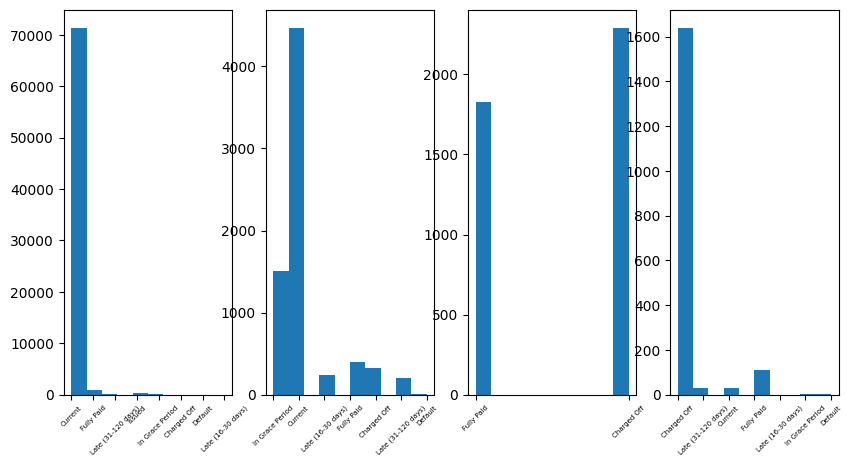

['ACTIVE' 'COMPLETE' 'COMPLETED' 'BROKEN']


In [183]:
plt.figure(figsize=(10, 5))
x=temp_data['hardship_status'].unique()[1:]
for i in range(len(x)):
    plt.subplot(1,len(x),i+1)
    plt.hist(df[df['hardship_status']==x[i]]['loan_status'])
    plt.xticks(rotation=45,fontsize=5)

plt.show()
print(x)

In [171]:
temp_data['hardship_loan_status'].value_counts()

hardship_loan_status
ACTIVE                69831
GRACE_CURRENT          6955
Late (16-30 days)      2606
INCOLLECTION           2074
In Grace Period        1543
Current                1365
DELINQUENT              836
CURRENT                 434
Late (31-120 days)      249
Issued                    6
PIPELINE                  4
OTHER                     4
ISSUED                    1
Name: count, dtype: int64

In [4]:
temp_data[temp_data['hardship_loan_status'].isna()]['loan_status'].value_counts()

loan_status
Fully Paid                                             895246
Current                                                542968
Charged Off                                            213092
Late (31-120 days)                                       9387
In Grace Period                                          4462
Late (16-30 days)                                        1347
Does not meet the credit policy. Status:Fully Paid       1223
Issued                                                    942
Does not meet the credit policy. Status:Charged Off       460
Default                                                   259
Name: count, dtype: int64

In [217]:
temp_data['hardship_loan_status'] = temp_data['hardship_loan_status'].str.lower()

In [189]:
temp_data['hardship_loan_status'].value_counts()

hardship_loan_status
active                69831
grace_current          6955
late (16-30 days)      2606
incollection           2074
current                1799
in grace period        1543
delinquent              836
late (31-120 days)      249
issued                    7
pipeline                  4
other                     4
Name: count, dtype: int64

In [227]:
status_mapping = {
    'current': 3,
    'active': 3,
    'issued': 3,
    'pipeline': 3,
    'in grace period': 2,
    'grace_current': 2,
    'late (16-30 days)': 2,
    'late (31-120 days)': 1,
    'delinquent': 1,
    'incollection': 1,
    'other': 0,
    'na': 0
}
temp_data['hardship_loan_status'].fillna('na',inplace=True)
temp_data['hardship_loan_status'] = temp_data['hardship_loan_status'].str.lower()
temp_data['hardship_loan_status'] = temp_data['hardship_loan_status'].map(status_mapping)

# 결과 출력
temp_data['hardship_loan_status'].value_counts()

hardship_loan_status
0    1669391
3      71641
2      11104
1       3159
Name: count, dtype: int64

In [223]:
temp_data['loan_status_code'].isna().sum()

1669387

In [225]:
temp_data['hardship_loan_status'].isna().sum()

1669387

In [212]:
temp_data['loan_status_code'].isna().sum()

1755295

In [191]:
temp_data[temp_data['hardship_loan_status'].notna()]['hardship_loan_status'].head()

4            active
45           active
135          active
140    incollection
193          active
Name: hardship_loan_status, dtype: object

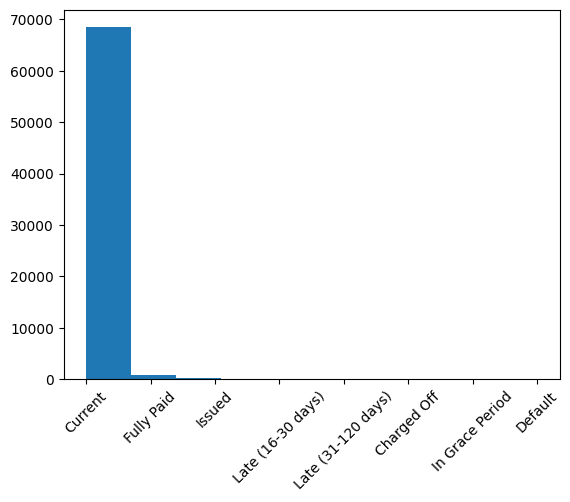

In [199]:
plt.hist(temp_data[temp_data['hardship_loan_status']=='active']['loan_status'])
plt.xticks(rotation=45,fontsize=10)
plt.show()

In [197]:

x=temp_data['hardship_loan_status'].unique()[1:]
x

array(['active', 'incollection', 'in grace period', 'grace_current',
       'delinquent', 'current', 'late (16-30 days)', 'late (31-120 days)',
       'pipeline', 'issued', 'other'], dtype=object)

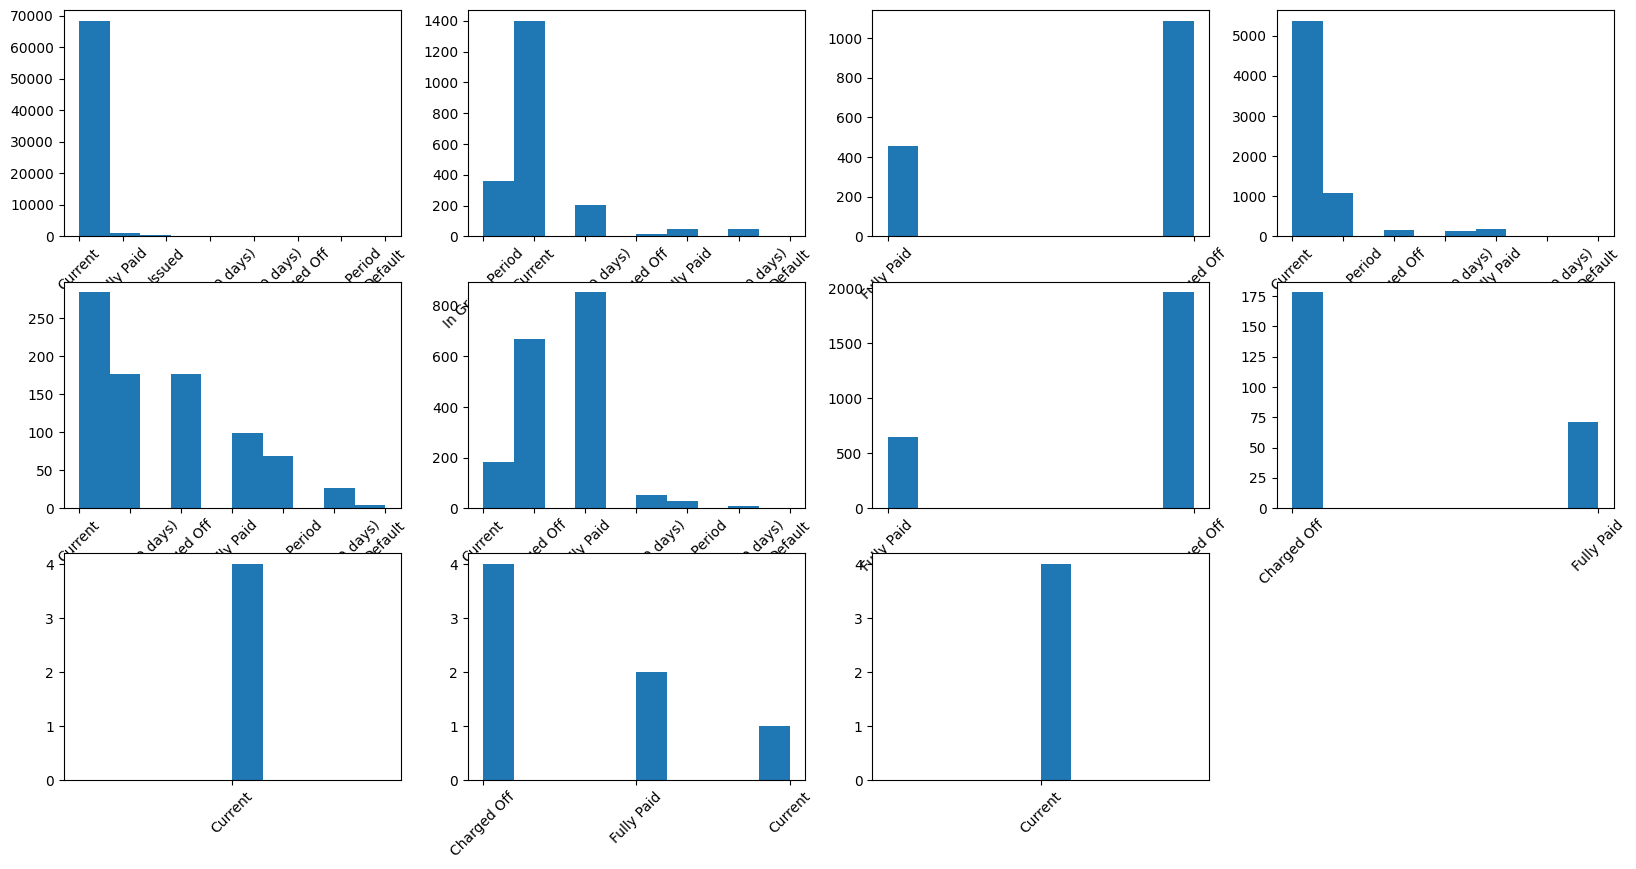

['active' 'incollection' 'in grace period' 'grace_current' 'delinquent'
 'current' 'late (16-30 days)' 'late (31-120 days)' 'pipeline' 'issued'
 'other']


In [201]:
plt.figure(figsize=(20, 10))
x=temp_data['hardship_loan_status'].unique()[1:]
for i in range(len(x)):
    plt.subplot(3,math.ceil(len(x)/3),i+1)
    plt.hist(temp_data[temp_data['hardship_loan_status']==x[i]]['loan_status'])
    plt.xticks(rotation=45,fontsize=10)

plt.show()
print(x)

In [164]:
df_tmp=pd.DataFrame({'a':[1,2,3,4,1,2,3,4],'b':['a','a','a','A','a','A','a','a']})
df_tmp

,a,b
0,1,a
1,2,a
2,3,a
3,4,A
4,1,a
5,2,A
6,3,a
7,4,a


In [165]:
df_tmp['b']=df_tmp['b'].str.lower()
df_tmp

,a,b
0,1,a
1,2,a
2,3,a
3,4,a
4,1,a
5,2,a
6,3,a
7,4,a


In [161]:
df[df['hardship_loan_status'].notna()]['loan_status'].value_counts()

loan_status
Current               75720
Charged Off            4274
Fully Paid             3276
In Grace Period        1587
Late (31-120 days)      453
Issued                  316
Late (16-30 days)       273
Default                   9
Name: count, dtype: int64

debt_settlement_flag 컬럼은 과연 필요한가?

In [82]:
temp_data['debt_settlement_flag'].value_counts()

debt_settlement_flag
N    1724502
Y      30792
Name: count, dtype: int64

In [93]:
# 이 컬럼은 못갚은 사람들에 대해 조사한 컬럼인듯함. fully paid가 11개 있는 건 설명 안되지만
df[df['debt_settlement_flag']=='Y']['loan_status'].value_counts()

loan_status
Charged Off                                            30585
Late (31-120 days)                                       142
Current                                                   25
Fully Paid                                                11
In Grace Period                                            8
Default                                                    8
Late (16-30 days)                                          7
Does not meet the credit policy. Status:Charged Off        6
Name: count, dtype: int64

DATE 컬럼들

In [78]:
temp_data[temp_data['hardship_start_date'].notna()]['hardship_start_date'].unique()

array(['May-2020', 'Apr-2020', 'Jan-2018', 'Jun-2018', 'Jan-2020',
       'May-2018', 'May-2019', 'Sep-2017', 'Oct-2017', 'Jun-2019',
       'Feb-2019', 'Nov-2017', 'Oct-2019', 'Nov-2018', 'Oct-2018',
       'Sep-2019', 'Nov-2019', 'May-2017', 'Sep-2018', 'Dec-2018',
       'Aug-2018', 'Feb-2020', 'Jul-2018', 'Mar-2019', 'Jul-2019',
       'Dec-2017', 'Jul-2017', 'Jul-2020', 'Apr-2018', 'Dec-2019',
       'Jan-2019', 'Aug-2019', 'Apr-2019', 'Jun-2017', 'Mar-2018',
       'Feb-2018', 'Aug-2020', 'Aug-2017', 'Mar-2020', 'Oct-2020',
       'Mar-2017', 'Sep-2020', 'Apr-2017', 'Jan-2017', 'Feb-2017',
       'Jun-2020'], dtype=object)

In [80]:
temp_data[temp_data['hardship_end_date'].notna()]['hardship_end_date'].unique()

array(['Jul-2020', 'Jun-2020', 'May-2020', 'Aug-2020', 'Apr-2018',
       'Aug-2018', 'Mar-2020', 'Jun-2018', 'Aug-2019', 'Nov-2017',
       'Jan-2018', 'Sep-2019', 'Dec-2017', 'May-2019', 'Dec-2019',
       'Feb-2019', 'Dec-2018', 'Nov-2019', 'Feb-2020', 'Oct-2017',
       'Aug-2017', 'Oct-2018', 'Sep-2018', 'Apr-2020', 'Apr-2019',
       'Nov-2018', 'Mar-2018', 'Jun-2019', 'Oct-2019', 'Jul-2019',
       'Sep-2017', 'Jan-2019', 'Jul-2017', 'Oct-2020', 'Jul-2018',
       'Sep-2020', 'Mar-2019', 'Feb-2018', 'May-2018', 'Jan-2020',
       'Jun-2017', 'Dec-2020', 'May-2017', 'Jan-2021', 'Nov-2020',
       'Apr-2017', 'Mar-2017'], dtype=object)

In [81]:
temp_data[temp_data['payment_plan_start_date'].notna()]['payment_plan_start_date'].unique()

array(['May-2020', 'Apr-2020', 'Mar-2020', 'Jun-2020', 'Jan-2018',
       'Jul-2018', 'Jan-2020', 'Jun-2018', 'Jun-2019', 'Sep-2017',
       'Nov-2017', 'Jul-2019', 'Mar-2019', 'Oct-2017', 'Oct-2019',
       'Dec-2018', 'Oct-2018', 'Sep-2019', 'Dec-2019', 'Jun-2017',
       'Sep-2018', 'Jan-2019', 'Feb-2020', 'Feb-2019', 'Feb-2018',
       'Apr-2019', 'Aug-2019', 'May-2019', 'Jul-2017', 'May-2017',
       'Aug-2020', 'May-2018', 'Jul-2020', 'Dec-2017', 'Nov-2018',
       'Mar-2018', 'Nov-2019', 'Aug-2018', 'Aug-2017', 'Apr-2018',
       'Oct-2020', 'Sep-2020', 'Mar-2017', 'Nov-2020', 'Apr-2017',
       'Feb-2017'], dtype=object)

In [ ]:
temp_data[temp_data['payment_plan_start_date'].notna()]['payment_plan_start_date']

ONE-HOT 인코딩

In [105]:
def onehot(x):
	one = OneHotEncoder()
	temp_data = x.select_dtypes(include='object')
	temp_final = pd.DataFrame()

	for col in temp_data.columns:
		one.fit(temp_data[col].values.reshape(-1,1))

		col_df = pd.DataFrame(one.transform(temp_data[col].values.reshape(-1,1)).toarray().astype(int), columns=one.get_feature_names_out([col]))
		temp_final = pd.concat([temp_final, col_df], axis=1)
	return temp_final

In [229]:
# hardship_status 랑 hardship_loan_status는 조금 애매함
onehot_list='''
hardship_flag
hardship_type
hardship_reason
debt_settlement_flag
'''
onehot_list=onehot_list.strip().split('\n')
onehot_data=temp_data[onehot_list]

In [230]:
temp_one=onehot(onehot_data)

In [233]:
temp_one.shape

(1755295, 34)

라벨 인코딩

In [155]:
from sklearn.preprocessing import OrdinalEncoder

cate_order=['NA','BROKEN','ACTIVE','COMPLETE','COMPLETED']
encoder=OrdinalEncoder(categories=[cate_order])

temp_data['hardship_status'] = temp_data['hardship_status'].fillna('NA')
temp_data['hardship_status'] = encoder.fit_transform(temp_data[['hardship_status']])
# unique_values, counts = np.unique(df2, return_counts=True)

# # 결과 출력
# for value, count in zip(unique_values, counts):
#     print(f"Value {value}: {count} times")


hardship_status
0.00000    1669261
2.00000      72952
3.00000       7148
4.00000       4118
1.00000       1816
Name: count, dtype: int64

In [140]:
temp_data['hardship_status'].value_counts()

hardship_status
ACTIVE       72952
COMPLETE      7148
COMPLETED     4118
BROKEN        1816
Name: count, dtype: int64

In [130]:
temp_data['hardship_start_date']=pd.to_datetime(temp_data['hardship_start_date'], format='%b-%Y').dt.to_period('M')
temp_data['hardship_end_date']=pd.to_datetime(temp_data['hardship_end_date'], format='%b-%Y').dt.to_period('M')
temp_data['payment_plan_start_date']=pd.to_datetime(temp_data['payment_plan_start_date'], format='%b-%Y').dt.to_period('M')

In [131]:
temp_data['hardship_start_date'].unique()

<PeriodArray>
[    'NaT', '2020-05', '2020-04', '2018-01', '2018-06', '2020-01', '2018-05',
 '2019-05', '2017-09', '2017-10', '2019-06', '2019-02', '2017-11', '2019-10',
 '2018-11', '2018-10', '2019-09', '2019-11', '2017-05', '2018-09', '2018-12',
 '2018-08', '2020-02', '2018-07', '2019-03', '2019-07', '2017-12', '2017-07',
 '2020-07', '2018-04', '2019-12', '2019-01', '2019-08', '2019-04', '2017-06',
 '2018-03', '2018-02', '2020-08', '2017-08', '2020-03', '2020-10', '2017-03',
 '2020-09', '2017-04', '2017-01', '2017-02', '2020-06']
Length: 47, dtype: period[M]

In [252]:
temp_data[temp_data['next_pymnt_d'].notna()]['loan_status'].value_counts()
# 얘는 학습때는 안쓰는게 맞다


loan_status
Current                                                618688
Late (31-120 days)                                       9840
In Grace Period                                          6049
Late (16-30 days)                                        1620
Issued                                                   1258
Does not meet the credit policy. Status:Fully Paid       1223
Does not meet the credit policy. Status:Charged Off       460
Default                                                   268
Name: count, dtype: int64

In [7]:
temp_data[temp_data['mo_sin_old_il_acct'].isna()]['loan_status'].value_counts()

loan_status
Fully Paid                                             59195
Current                                                18340
Charged Off                                            13290
Does not meet the credit policy. Status:Fully Paid      1223
Does not meet the credit policy. Status:Charged Off      460
Late (31-120 days)                                       419
In Grace Period                                          223
Late (16-30 days)                                         78
Default                                                    9
Issued                                                     8
Name: count, dtype: int64

In [8]:
temp_data['mo_sin_old_il_acct'].isna().sum()

93246

In [16]:
temp_data['mo_sin_old_il_acct'].describe()

count   1662049.00000
mean        125.86321
std          54.40654
min           0.00000
25%          93.00000
50%         130.00000
75%         155.00000
max         999.00000
Name: mo_sin_old_il_acct, dtype: float64

In [10]:
59195/93246

0.6348261587628423

In [15]:
tmp_df1=temp_data[temp_data['mo_sin_old_il_acct'].notna()]
t1=tmp_df1.shape[0]
tmp_unique=tmp_df1['mo_sin_old_il_acct'].unique()
tmp_unique.sort()


x_revol=[]
y_revol=[]

for i in tmp_unique:
    real_tmp=tmp_df1[tmp_df1['mo_sin_old_il_acct']==i]
    total_count=real_tmp.shape[0]
    count_tmp=(real_tmp['loan_status']=='Fully Paid').sum()
    ratio=count_tmp/total_count
    print(f'{i}\t {total_count}\t {ratio:.2f}')
    x_revol.append(int(i))
    y_revol.append(ratio)

0.0	 14	 0.50
1.0	 358	 0.50
2.0	 701	 0.49
3.0	 1061	 0.50
4.0	 1207	 0.48
5.0	 1310	 0.51
6.0	 1497	 0.47
7.0	 1916	 0.49
8.0	 2070	 0.51
9.0	 2088	 0.47
10.0	 2288	 0.49
11.0	 2398	 0.47
12.0	 2598	 0.46
13.0	 3246	 0.48
14.0	 3322	 0.45
15.0	 3206	 0.46
16.0	 3158	 0.46
17.0	 3058	 0.48
18.0	 3046	 0.49
19.0	 3217	 0.48
20.0	 3174	 0.45
21.0	 3362	 0.45
22.0	 3376	 0.47
23.0	 3431	 0.47
24.0	 3598	 0.48
25.0	 3592	 0.48
26.0	 3499	 0.46
27.0	 3602	 0.45
28.0	 3508	 0.46
29.0	 3593	 0.45
30.0	 3701	 0.48
31.0	 3808	 0.46
32.0	 3828	 0.45
33.0	 3881	 0.45
34.0	 4021	 0.46
35.0	 4052	 0.45
36.0	 4424	 0.46
37.0	 4620	 0.44
38.0	 4877	 0.45
39.0	 4675	 0.45
40.0	 4708	 0.45
41.0	 4653	 0.45
42.0	 4680	 0.44
43.0	 4808	 0.45
44.0	 4715	 0.45
45.0	 4728	 0.44
46.0	 5048	 0.45
47.0	 5060	 0.44
48.0	 4980	 0.44
49.0	 4993	 0.45
50.0	 5037	 0.45
51.0	 5085	 0.46
52.0	 4942	 0.45
53.0	 4968	 0.44
54.0	 5090	 0.45
55.0	 5065	 0.45
56.0	 5023	 0.44
57.0	 5274	 0.45
58.0	 5049	 0.44
59.0	 5124	

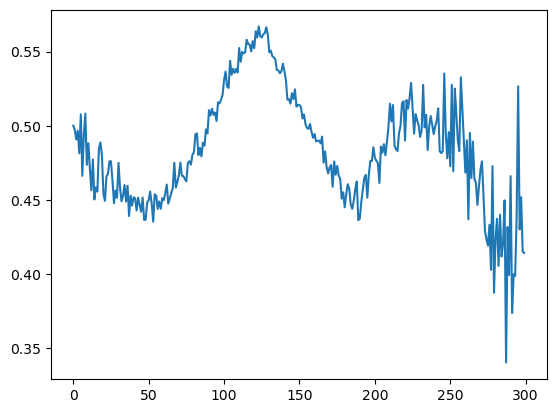

In [14]:
plt.plot(x_revol[:300],y_revol[:300])
plt.show()

In [7]:
# 이상치처리
# revol_util - 리볼빙 사용률
# revol_bal - 리볼빙 잔액(아직 안갚은 총액)

print(temp_data['revol_bal'].describe())
temp_data['revol_util'].describe()

count   1755294.00000
mean      16947.52261
std       22869.97912
min           0.00000
25%        5990.00000
50%       11483.00000
75%       20635.00000
max     2568995.00000
Name: revol_bal, dtype: float64


count     1753707
unique       1334
top            0%
freq        11409
Name: revol_util, dtype: object

In [31]:
# revol_util은 이상치가 확실하다.. 제거해야하나?
# 일반적으로 100%을 넘을 순 없지만 특수한 경우 가능하고, 데이터셋에도 많은 데이터가 100%을 넘음
# 하지만 200을 넘는건 혼자고 심지어 366

In [9]:
temp_data['revol_util'] = temp_data['revol_util'].str.rstrip('%').astype(float)

In [17]:
temp_data[temp_data['revol_util']>200]['revol_util'].value_counts()

revol_util
366.60000    1
Name: count, dtype: int64

In [29]:
print(temp_data[temp_data['revol_util']>200]['loan_status'])
temp_data[temp_data['revol_util']>200]['grade']

1638961    Charged Off
Name: loan_status, dtype: object


1638961    C
Name: grade, dtype: object

In [7]:
temp_data[temp_data['annual_inc']>10000000]['fico_range_high']

773802    699.00000
1047205   694.00000
Name: fico_range_high, dtype: float64

In [26]:
# revol bal은 이상치가 아닌 것 같은데..
# 1.5 ~  2.5 사이가 텅 빈 것도 아님

In [25]:
temp_data[temp_data['revol_bal']>1500000]['revol_bal']

128275   1746716.00000
396682   1803041.00000
401404   2358150.00000
586273   1743266.00000
611992   1678904.00000
731624   2559552.00000
982291   1630818.00000
996628   2568995.00000
Name: revol_bal, dtype: float64

In [20]:
temp_data[temp_data['revol_bal']>2000000]['grade']

401404    B
731624    A
996628    A
Name: grade, dtype: object

In [24]:
temp_data[temp_data['revol_bal']>2000000]['emp_title']
# Jennison Associates은 뉴욕에 본사를 둔 investment advisers 회사
# Managing Director 는 이사, 사업 대표

401404     Managing Director 
731624      Managing Director
996628    Jennison Associates
Name: emp_title, dtype: object

In [32]:
# last_fico_range_high
# last_fico_range_low

In [39]:
temp_data['last_fico_range_high'].describe()

count   1755294.00000
mean        690.39915
std          74.77549
min           0.00000
25%         654.00000
50%         699.00000
75%         739.00000
max         850.00000
Name: last_fico_range_high, dtype: float64

In [67]:
temp_data[temp_data['last_fico_range_high']<500]['last_fico_range_high'].value_counts()

last_fico_range_high
499.00000    30197
0.00000        129
Name: count, dtype: int64

In [42]:
temp_data[temp_data['last_fico_range_high']==0]['last_fico_range_high'].count()

129

In [60]:
# 얘네의 정체를 규명해야함
temp_data[temp_data['last_fico_range_low']==0]['last_fico_range_high'].value_counts()

last_fico_range_high
499.00000    30197
0.00000        129
Name: count, dtype: int64

In [46]:
(temp_data['last_fico_range_high']-temp_data['last_fico_range_low']).value_counts()

4.00000      1724631
499.00000      30197
5.00000          337
0.00000          129
Name: count, dtype: int64

In [59]:
# 상한 하한 차이가 5인놈들은 845~850인 애들
temp_data[(temp_data['last_fico_range_high']-temp_data['last_fico_range_low'])==5]['last_fico_range_high'].value_counts()

last_fico_range_high
850.00000    337
Name: count, dtype: int64

In [69]:
# 30197명은 진짜 신용평가가 안좋은 애들이라 low점수를 495로 맞춰주거나, low열을 빼버리면 된다
temp_data[(temp_data['last_fico_range_high']==499) & (temp_data['last_fico_range_low']==0)]['grade'].value_counts()

grade
C    10195
D     7202
B     5868
E     3652
A     1510
F     1327
G      443
Name: count, dtype: int64

In [73]:
temp_data[(temp_data['last_fico_range_high']==0) & (temp_data['last_fico_range_low']==0)]['loan_status'].value_counts()

loan_status
Fully Paid                                            113
Charged Off                                            12
Current                                                 3
Does not meet the credit policy. Status:Fully Paid      1
Name: count, dtype: int64

In [58]:
temp_data['grade'].value_counts()

grade
B    515082
C    481313
A    393726
D    249328
E     83213
F     25303
G      7329
Name: count, dtype: int64

In [51]:
# 0(low)~ 499(high) 받은 30197 명이랑, 0 ~ 0 받은 129명은 누구냐?

# na값 처리 - mths_since_recent_bc_dlq

중앙값 대체 추천

In [21]:
temp_data['mths_since_recent_bc_dlq'].isna().sum()

1365589

In [30]:
temp_data['mths_since_recent_bc_dlq'].describe()

count   389706.00000
mean        39.30684
std         22.55492
min          0.00000
25%         21.00000
50%         37.00000
75%         57.00000
max        202.00000
Name: mths_since_recent_bc_dlq, dtype: float64

In [3]:
temp_data[temp_data['mths_since_recent_bc_dlq'].isna()]['loan_status'].value_counts()

loan_status
Fully Paid                                             690439
Current                                                494288
Charged Off                                            164606
Late (31-120 days)                                       7650
In Grace Period                                          4510
Does not meet the credit policy. Status:Fully Paid       1223
Late (16-30 days)                                        1208
Issued                                                   1011
Does not meet the credit policy. Status:Charged Off       460
Default                                                   193
Name: count, dtype: int64

In [4]:
temp_data['loan_status'].value_counts()

loan_status
Fully Paid                                             898522
Current                                                618688
Charged Off                                            217366
Late (31-120 days)                                       9840
In Grace Period                                          6049
Late (16-30 days)                                        1620
Issued                                                   1258
Does not meet the credit policy. Status:Fully Paid       1223
Does not meet the credit policy. Status:Charged Off       460
Default                                                   268
Name: count, dtype: int64

In [22]:
temp_data[temp_data['mths_since_recent_bc_dlq'].isna()]['loan_status'].value_counts()

loan_status
Fully Paid                                             690439
Current                                                494288
Charged Off                                            164606
Late (31-120 days)                                       7650
In Grace Period                                          4510
Does not meet the credit policy. Status:Fully Paid       1223
Late (16-30 days)                                        1208
Issued                                                   1011
Does not meet the credit policy. Status:Charged Off       460
Default                                                   193
Name: count, dtype: int64

In [34]:
tmp_df1=temp_data[temp_data['mths_since_recent_bc_dlq'].notna()]
t1=tmp_df1.shape[0]
tmp_unique=tmp_df1['mths_since_recent_bc_dlq'].unique()
tmp_unique.sort()

x_revol=[]
y_revol=[]

for i in tmp_unique:
    real_tmp=tmp_df1[tmp_df1['mths_since_recent_bc_dlq']==i]
    total_count=real_tmp.shape[0]
    count_tmp=(real_tmp['loan_status']=='Fully Paid').sum()
    ratio=count_tmp/total_count
    print(f'{i}\t {total_count}\t {ratio:.2f}')
    x_revol.append(int(i))
    y_revol.append(ratio)

0.0	 489	 0.74
1.0	 1735	 0.66
2.0	 2120	 0.59
3.0	 2948	 0.56
4.0	 3469	 0.55
5.0	 3872	 0.57
6.0	 4577	 0.54
7.0	 4550	 0.55
8.0	 4679	 0.56
9.0	 4885	 0.55
10.0	 4755	 0.54
11.0	 4927	 0.56
12.0	 5887	 0.52
13.0	 5773	 0.53
14.0	 5704	 0.53
15.0	 5807	 0.52
16.0	 5639	 0.52
17.0	 5602	 0.52
18.0	 5930	 0.51
19.0	 6055	 0.52
20.0	 5821	 0.52
21.0	 5808	 0.52
22.0	 6034	 0.52
23.0	 5803	 0.51
24.0	 6124	 0.50
25.0	 6210	 0.52
26.0	 6159	 0.52
27.0	 6059	 0.51
28.0	 6113	 0.52
29.0	 6009	 0.52
30.0	 6022	 0.52
31.0	 5933	 0.51
32.0	 5954	 0.51
33.0	 6024	 0.51
34.0	 5902	 0.52
35.0	 5997	 0.52
36.0	 5984	 0.51
37.0	 5851	 0.52
38.0	 5821	 0.53
39.0	 5771	 0.54
40.0	 5718	 0.54
41.0	 5667	 0.53
42.0	 5853	 0.53
43.0	 5980	 0.51
44.0	 5920	 0.52
45.0	 5987	 0.53
46.0	 5800	 0.52
47.0	 5784	 0.53
48.0	 5893	 0.54
49.0	 4903	 0.54
50.0	 3343	 0.55
51.0	 3547	 0.53
52.0	 3433	 0.55
53.0	 3614	 0.54
54.0	 3682	 0.54
55.0	 3572	 0.54
56.0	 3674	 0.55
57.0	 3774	 0.53
58.0	 3701	 0.54
59.0	 36

<function matplotlib.pyplot.show(close=None, block=None)>

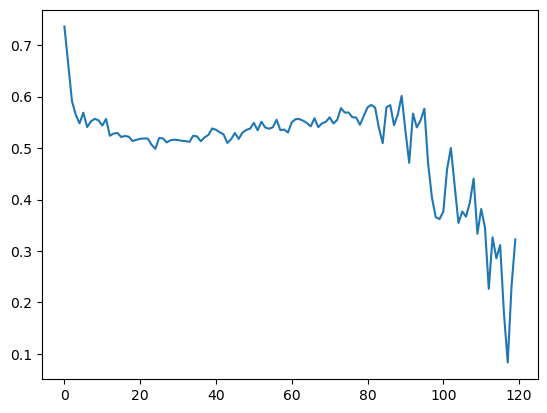

In [35]:
plt.plot(x_revol[:120],y_revol[:120])
plt.show

# na값 처리 - mths_since_recent_revol_delinq

'mths_since_recent_bc_dlq' 랑 상관계수 높음


'mths_since_last_delinq','mths_since_last_major_derog','mths_since_recent_bc_dlq'

중앙값대체 추천

In [25]:
temp_data['mths_since_recent_revol_delinq'].isna().sum()

1197241

In [28]:
temp_data['mths_since_recent_revol_delinq'].describe()

count   558054.00000
mean        36.06440
std         22.26379
min          0.00000
25%         18.00000
50%         33.00000
75%         51.00000
max        212.00000
Name: mths_since_recent_revol_delinq, dtype: float64

In [3]:
temp_data[temp_data['mths_since_recent_revol_delinq']==33]['loan_status'].value_counts()

loan_status
Fully Paid            4445
Current               3043
Charged Off           1096
In Grace Period         45
Late (31-120 days)      44
Late (16-30 days)       12
Issued                   5
Default                  3
Name: count, dtype: int64

In [27]:
temp_data[temp_data['mths_since_recent_revol_delinq'].isna()]['loan_status'].value_counts()

loan_status
Fully Paid                                             602040
Current                                                437443
Charged Off                                            143421
Late (31-120 days)                                       6667
In Grace Period                                          3856
Does not meet the credit policy. Status:Fully Paid       1223
Late (16-30 days)                                        1043
Issued                                                    913
Does not meet the credit policy. Status:Charged Off       460
Default                                                   174
Name: count, dtype: int64

In [41]:
corr_list=['mths_since_recent_revol_delinq',
          'mths_since_last_delinq',
           'mths_since_last_major_derog',
           'mths_since_recent_bc_dlq']

x=temp_data[corr_list]

(array([1.74914e+05, 1.82012e+05, 1.16281e+05, 8.06500e+04, 2.86200e+03,
        1.04600e+03, 2.19000e+02, 5.50000e+01, 1.10000e+01, 4.00000e+00]),
 array([  0. ,  21.2,  42.4,  63.6,  84.8, 106. , 127.2, 148.4, 169.6,
        190.8, 212. ]),
 <BarContainer object of 10 artists>)

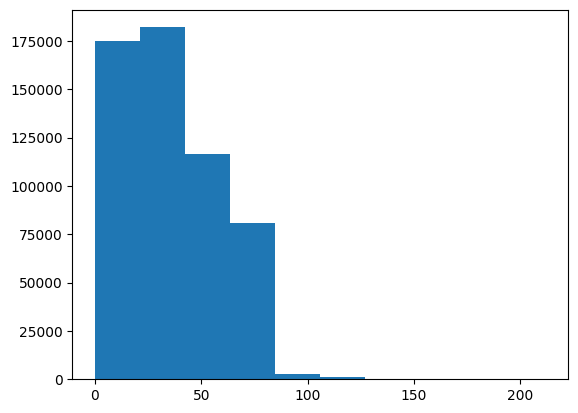

In [277]:
plt.hist(temp_data['mths_since_recent_revol_delinq'])

In [331]:
tmp_df1=temp_data[temp_data['mths_since_recent_revol_delinq'].notna()]
t1=tmp_df1.shape[0]
tmp_unique=tmp_df1['mths_since_recent_revol_delinq'].unique()
tmp_unique.sort()
t1

558054

In [332]:
#'mths_since_recent_revol_delinq' 컬럼 na값 0? 170만명중에 115만명은 연체가 없다고 보는게 합당한가?
# 전체 fullypaid 비율은 약 51% -> 20~50개월까지 평균 51%나옴. 20~50 사이의 수 무작위로 채우기?
x_revol=[]
y_revol=[]

for i in tmp_unique:
    real_tmp=tmp_df1[tmp_df1['mths_since_recent_revol_delinq']==i]
    total_count=real_tmp.shape[0]
    count_tmp=(real_tmp['loan_status']=='Fully Paid').sum()
    ratio=count_tmp/total_count
    print(f'{i}\t {total_count}\t {ratio:.2f}')
    x_revol.append(int(i))
    y_revol.append(ratio)

0.0	 829	 0.74
1.0	 3134	 0.68
2.0	 4101	 0.60
3.0	 5584	 0.57
4.0	 6466	 0.57
5.0	 7326	 0.58
6.0	 8647	 0.55
7.0	 8804	 0.55
8.0	 8604	 0.56
9.0	 8993	 0.56
10.0	 8559	 0.55
11.0	 8734	 0.55
12.0	 10196	 0.53
13.0	 9892	 0.54
14.0	 9548	 0.54
15.0	 9533	 0.53
16.0	 9238	 0.54
17.0	 9083	 0.53
18.0	 9542	 0.52
19.0	 9589	 0.53
20.0	 9189	 0.51
21.0	 9323	 0.52
22.0	 9251	 0.52
23.0	 8806	 0.51
24.0	 9371	 0.50
25.0	 9470	 0.52
26.0	 9289	 0.52
27.0	 9115	 0.51
28.0	 9214	 0.52
29.0	 8961	 0.52
30.0	 8931	 0.51
31.0	 8524	 0.51
32.0	 8685	 0.51
33.0	 8693	 0.51
34.0	 8456	 0.52
35.0	 8504	 0.52
36.0	 8441	 0.51
37.0	 8255	 0.52
38.0	 8217	 0.52
39.0	 8098	 0.53
40.0	 7938	 0.54
41.0	 7787	 0.53
42.0	 8006	 0.52
43.0	 8019	 0.51
44.0	 8040	 0.51
45.0	 7838	 0.52
46.0	 7783	 0.51
47.0	 7569	 0.52
48.0	 7582	 0.52
49.0	 6365	 0.52
50.0	 4291	 0.54
51.0	 4506	 0.53
52.0	 4357	 0.53
53.0	 4530	 0.53
54.0	 4534	 0.52
55.0	 4464	 0.54
56.0	 4464	 0.54
57.0	 4568	 0.53
58.0	 4518	 0.52
59.0	 4

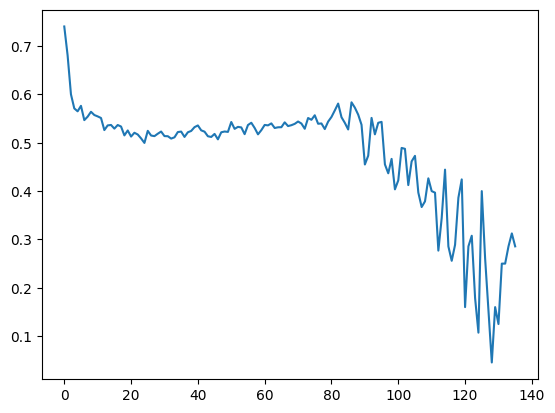

In [363]:
plt.plot(x_revol[:136],y_revol[:136])
plt.show()
# 대부분의 자료는 80이하에 분포. 그러니까 전체적으로 loan_status 전체 분포랑 비슷하지만, 값이 너무 높으면 fulllypaid비율이 유의미하게 낮아짐
# 1)0으로 대체 2)0~80사이 값으로 대체 3)20~50사이 값으로 대체

In [7]:
temp_data['mths_since_recent_revol_delinq'].value_counts()

mths_since_recent_revol_delinq
12.00000     10196
13.00000      9892
19.00000      9589
14.00000      9548
18.00000      9542
15.00000      9533
25.00000      9470
24.00000      9371
21.00000      9323
26.00000      9289
22.00000      9251
16.00000      9238
28.00000      9214
20.00000      9189
27.00000      9115
17.00000      9083
9.00000       8993
29.00000      8961
30.00000      8931
23.00000      8806
7.00000       8804
11.00000      8734
33.00000      8693
32.00000      8685
6.00000       8647
8.00000       8604
10.00000      8559
31.00000      8524
35.00000      8504
34.00000      8456
36.00000      8441
37.00000      8255
38.00000      8217
39.00000      8098
44.00000      8040
43.00000      8019
42.00000      8006
40.00000      7938
45.00000      7838
41.00000      7787
46.00000      7783
48.00000      7582
47.00000      7569
5.00000       7326
4.00000       6466
49.00000      6365
3.00000       5584
67.00000      4845
66.00000      4811
69.00000      4783
72.00000      4741


In [5]:
temp_data[temp_data['mths_since_recent_revol_delinq'].isna()]['loan_status'].value_counts()

loan_status
Fully Paid                                             602040
Current                                                437443
Charged Off                                            143421
Late (31-120 days)                                       6667
In Grace Period                                          3856
Does not meet the credit policy. Status:Fully Paid       1223
Late (16-30 days)                                        1043
Issued                                                    913
Does not meet the credit policy. Status:Charged Off       460
Default                                                   174
Name: count, dtype: int64

In [254]:
temp_data['loan_status'].value_counts()

loan_status
Fully Paid                                             898522
Current                                                618688
Charged Off                                            217366
Late (31-120 days)                                       9840
In Grace Period                                          6049
Late (16-30 days)                                        1620
Issued                                                   1258
Does not meet the credit policy. Status:Fully Paid       1223
Does not meet the credit policy. Status:Charged Off       460
Default                                                   268
Name: count, dtype: int64

In [335]:
898522/temp_data.shape[0] # 전체에서 fully paid 비율

0.5118923030031989

In [327]:
temp_data[temp_data['mths_since_recent_revol_delinq'].notna()]['loan_amnt'].mean()

14945.090887261806

In [330]:
temp_data['loan_amnt'].mean()

15350.786463692122

In [365]:
temp_data[temp_data['mths_since_recent_revol_delinq'].isna()]['loan_status'].value_counts()
# 전체 데이터 중 loan_status가 does not meet~인 행은 전부 mths_since_recent_revol_delinq가 결측치임
# 분포가 loan_status랑 거의 같다. 즉 결측치를 0으로 처리하면 문제가되는 부분임\
# 하지만 0으로 써주는 애들이 착하고 부지런한 애들이면 fullypaid높은거 설명은 가능해서 0으로 처리해도 될거같긴한데..
# 근데 그러면 1~3 값도 높은게 설명이 안됨

loan_status
Fully Paid                                             602040
Current                                                437443
Charged Off                                            143421
Late (31-120 days)                                       6667
In Grace Period                                          3856
Does not meet the credit policy. Status:Fully Paid       1223
Late (16-30 days)                                        1043
Issued                                                    913
Does not meet the credit policy. Status:Charged Off       460
Default                                                   174
Name: count, dtype: int64

# NA값 처리 - num_sats

In [5]:
cor_list=['open_acc','num_sats']

In [6]:
temp_data[cor_list].corr(method='pearson')

,open_acc,num_sats
open_acc,1.00000,0.99914
num_sats,0.99914,1.00000


In [9]:
temp_data[cor_list].head(10)

,open_acc,num_sats
0,14.00000,14.00000
1,6.00000,6.00000
2,24.00000,24.00000
3,22.00000,22.00000
4,10.00000,10.00000
5,18.00000,18.00000
6,7.00000,7.00000
7,19.00000,19.00000
8,10.00000,10.00000
9,14.00000,14.00000


In [37]:
x=temp_data[cor_list]
x[x['open_acc']==x['num_sats']].shape

(1672541, 2)

num_sats의 결측치는 open_acc 값으로 채우면 됨 / 
밑에 코드의 x를 temp_data로 바꾸면됨

In [34]:
x['num_sats']=x['num_sats'].fillna(x['open_acc'])

In [35]:
x['num_sats'].isna().sum()

17

In [32]:
temp_data['open_acc'].isna().sum()

17

In [342]:
temp_data[temp_data['num_sats'].isna()]['loan_status'].value_counts()

loan_status
Fully Paid                                             28453
Charged Off                                             4976
Does not meet the credit policy. Status:Fully Paid      1223
Does not meet the credit policy. Status:Charged Off      460
Name: count, dtype: int64

In [9]:
df['grade'].isna().sum()

1

In [357]:
tmp_df=temp_data[temp_data['num_sats'].notna()]

tmp_unique_list=tmp_df['num_sats'].unique()
tmp_unique_list.sort()
x_sat=[]
y_sat=[]


for i in tmp_unique_list:
    real_tmp=tmp_df[tmp_df['num_sats']==i]
    total_count=real_tmp.shape[0]
    
    count_tmp=(real_tmp['loan_status']=='Fully Paid').sum()
    ratio=count_tmp/total_count
    print(f'{i}\t {total_count}\t {ratio:.2f}')
    x_sat.append(int(i))
    y_sat.append(ratio)

0.0	 67	 0.28
1.0	 1383	 0.35
2.0	 8649	 0.40
3.0	 24948	 0.45
4.0	 51900	 0.49
5.0	 82443	 0.50
6.0	 110191	 0.51
7.0	 130190	 0.52
8.0	 142030	 0.52
9.0	 147178	 0.52
10.0	 142512	 0.52
11.0	 132184	 0.52
12.0	 118743	 0.51
13.0	 104042	 0.51
14.0	 90086	 0.51
15.0	 76118	 0.50
16.0	 63877	 0.50
17.0	 53651	 0.50
18.0	 44183	 0.49
19.0	 36562	 0.50
20.0	 29697	 0.49
21.0	 24436	 0.48
22.0	 19935	 0.48
23.0	 16321	 0.48
24.0	 13124	 0.47
25.0	 10722	 0.46
26.0	 8421	 0.45
27.0	 6870	 0.46
28.0	 5595	 0.44
29.0	 4546	 0.45
30.0	 3745	 0.43
31.0	 2883	 0.43
32.0	 2371	 0.44
33.0	 2017	 0.43
34.0	 1548	 0.44
35.0	 1318	 0.41
36.0	 1041	 0.41
37.0	 850	 0.40
38.0	 689	 0.41
39.0	 561	 0.40
40.0	 454	 0.37
41.0	 370	 0.43
42.0	 318	 0.42
43.0	 213	 0.38
44.0	 192	 0.34
45.0	 179	 0.40
46.0	 120	 0.38
47.0	 102	 0.45
48.0	 95	 0.38
49.0	 81	 0.32
50.0	 58	 0.41
51.0	 51	 0.41
52.0	 51	 0.41
53.0	 45	 0.42
54.0	 28	 0.39
55.0	 28	 0.36
56.0	 24	 0.46
57.0	 16	 0.31
58.0	 18	 0.39
59.0	 12	 0

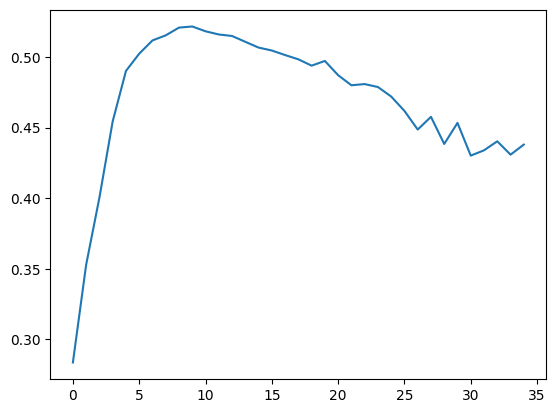

In [364]:
# 대부분의 데이터는 0에서 25사이에 위치해 있음
# 결측치 0으로 하면 안됨
# 결측치 가지는 애들이 80%로 fully paid라 잘 갚는 애들인걸 반영해야 하는데..
# 1) 평균인 5~20 사이의 랜덤값? 2) 피크인 10으로 대체

plt.plot(x_sat[:35],y_sat[:35])
plt.show()

In [8]:
df[df['num_sats']==94]['purpose']

1019737    debt_consolidation
Name: purpose, dtype: object

In [346]:
temp_data[temp_data['num_sats'].notna()]['num_sats'].value_counts()

num_sats
9.00000      147178
10.00000     142512
8.00000      142030
11.00000     132184
7.00000      130190
12.00000     118743
6.00000      110191
13.00000     104042
14.00000      90086
5.00000       82443
15.00000      76118
16.00000      63877
17.00000      53651
4.00000       51900
18.00000      44183
19.00000      36562
20.00000      29697
3.00000       24948
21.00000      24436
22.00000      19935
23.00000      16321
24.00000      13124
25.00000      10722
2.00000        8649
26.00000       8421
27.00000       6870
28.00000       5595
29.00000       4546
30.00000       3745
31.00000       2883
32.00000       2371
33.00000       2017
34.00000       1548
1.00000        1383
35.00000       1318
36.00000       1041
37.00000        850
38.00000        689
39.00000        561
40.00000        454
41.00000        370
42.00000        318
43.00000        213
44.00000        192
45.00000        179
46.00000        120
47.00000        102
48.00000         95
49.00000         81
0.00000    

# NA값 처리 - revol_util

percent_bc_gt_75 - 0.71, bc_util - 0.83

결측치 0

In [4]:
temp_data[temp_data['revol_util'].isna()]['bc_util'].isna().sum()

1588

In [5]:
temp_data['revol_util'].isna().sum()

1588

In [6]:
temp_data[temp_data['revol_util'].isna()]['loan_status'].value_counts()

loan_status
Current                                                698
Fully Paid                                             671
Charged Off                                            169
Does not meet the credit policy. Status:Fully Paid      19
In Grace Period                                         13
Late (31-120 days)                                      13
Does not meet the credit policy. Status:Charged Off      3
Issued                                                   1
Name: count, dtype: int64

In [6]:
698/1588

0.43954659949622166

In [ ]:
temp_data['revol_util'].head()

In [5]:
# %떼고 100으로 나눠줌
temp_data['revol_util'] = temp_data['revol_util'].str.rstrip('%').astype(float)
temp_data['revol_util']=temp_data['revol_util']/100

In [7]:
temp_data['revol_util'].head()

0   0.14000
1   0.35400
2   0.55900
3   0.12100
4   0.35500
Name: revol_util, dtype: float64

In [8]:
temp_data['revol_util'].describe()

count   1753707.00000
mean          0.48962
std           0.24899
min           0.00000
25%           0.29800
50%           0.48500
75%           0.68100
max           3.66600
Name: revol_util, dtype: float64

In [12]:
temp_data[temp_data['revol_util']==0]['loan_status'].value_counts()

loan_status
Fully Paid                                             5407
Current                                                4590
Charged Off                                            1208
Late (31-120 days)                                       84
In Grace Period                                          48
Does not meet the credit policy. Status:Fully Paid       34
Late (16-30 days)                                        14
Issued                                                   12
Does not meet the credit policy. Status:Charged Off      11
Default                                                   1
Name: count, dtype: int64

In [10]:
tmp_df1=temp_data[temp_data['revol_util'].notna()]
t1=tmp_df1.shape[0]
tmp_unique=tmp_df1['revol_util'].unique()
tmp_unique.sort()

x_revol=[]
y_revol=[]

for i in tmp_unique:
    real_tmp=tmp_df1[tmp_df1['revol_util']==i]
    total_count=real_tmp.shape[0]
    count_tmp=(real_tmp['loan_status']=='Fully Paid').sum()
    ratio=count_tmp/total_count
    #print(f'{i}\t {total_count}\t {ratio:.2f}')
    if total_count>100:
        x_revol.append(i)
        y_revol.append(ratio)
        print(f'{i:.2f}\t {total_count}\t {ratio:.2f}')

0.00	 11409	 0.47
0.00	 1461	 0.49
0.00	 1199	 0.48
0.00	 1077	 0.48
0.00	 942	 0.49
0.01	 914	 0.50
0.01	 865	 0.49
0.01	 818	 0.51
0.01	 842	 0.50
0.01	 810	 0.50
0.01	 879	 0.50
0.01	 793	 0.51
0.01	 785	 0.50
0.01	 795	 0.52
0.01	 782	 0.51
0.01	 776	 0.52
0.02	 793	 0.50
0.02	 813	 0.48
0.02	 786	 0.47
0.02	 716	 0.49
0.02	 873	 0.53
0.02	 786	 0.50
0.02	 797	 0.50
0.02	 800	 0.49
0.02	 755	 0.48
0.03	 836	 0.51
0.03	 769	 0.47
0.03	 781	 0.53
0.03	 822	 0.50
0.03	 790	 0.51
0.03	 894	 0.49
0.03	 844	 0.49
0.03	 808	 0.52
0.03	 829	 0.52
0.03	 817	 0.47
0.04	 777	 0.51
0.04	 856	 0.49
0.04	 804	 0.49
0.04	 855	 0.48
0.04	 843	 0.50
0.04	 896	 0.47
0.04	 888	 0.51
0.04	 840	 0.47
0.04	 882	 0.51
0.04	 851	 0.50
0.04	 862	 0.48
0.05	 876	 0.50
0.05	 825	 0.47
0.05	 945	 0.48
0.05	 884	 0.49
0.05	 948	 0.49
0.05	 899	 0.47
0.05	 886	 0.52
0.05	 931	 0.50
0.05	 897	 0.49
0.06	 859	 0.49
0.06	 930	 0.48
0.06	 928	 0.50
0.06	 941	 0.47
0.06	 913	 0.49
0.06	 963	 0.50
0.06	 956	 0.50
0.0

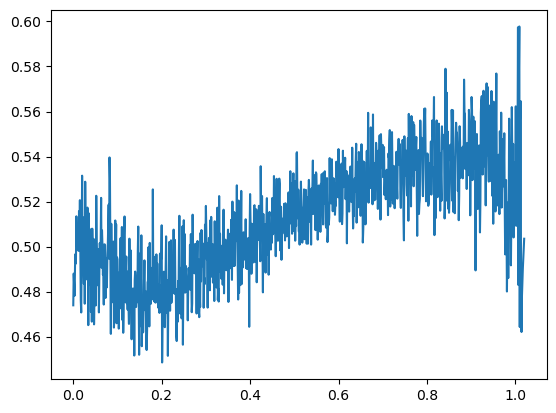

In [11]:
plt.plot(x_revol,y_revol)
plt.show()

# NA값 처리 - bc_open_to_buy

total_rev_hi_lim - 0.61, total_bc_limit - 0.77, bc_util - (-0.71)

1000,2000,3000 ... 에서 값 많음. 51,53,54,52... 크게 차이 없다.
0에선 자료도 많고 57%로 fully 비율이 높아서..
결측치 0으로 채우고싶네...

결측치 0으로 채우고 싶음

In [5]:
temp_data[temp_data['bc_open_to_buy'].isna()]['bc_util'].isna().sum()

49537

In [3]:
temp_data[temp_data['bc_open_to_buy'].isna()]['total_bc_limit'].isna().sum()

29985

In [4]:
temp_data[temp_data['bc_open_to_buy'].isna()]['total_rev_hi_lim'].isna().sum()

30133

In [17]:
temp_data[temp_data['bc_open_to_buy'].isna()]['loan_status'].value_counts() # 68%

loan_status
Fully Paid                                             33881
Current                                                 7087
Charged Off                                             6624
Does not meet the credit policy. Status:Fully Paid      1223
Does not meet the credit policy. Status:Charged Off      460
Late (31-120 days)                                       128
In Grace Period                                           94
Late (16-30 days)                                         25
Issued                                                     8
Default                                                    6
Name: count, dtype: int64

In [5]:
temp_data['bc_open_to_buy'].describe()

count   1705758.00000
mean      12679.25971
std       17841.99822
min           0.00000
25%        2000.00000
50%        6254.00000
75%       16147.00000
max      781431.00000
Name: bc_open_to_buy, dtype: float64

In [7]:
temp_data[temp_data['bc_open_to_buy']==0]['loan_status'].value_counts("")

loan_status
Fully Paid            12224
Current                5021
Charged Off            4017
Late (31-120 days)      100
In Grace Period          94
Late (16-30 days)        21
Issued                    7
Default                   4
Name: count, dtype: int64

In [16]:
tmp_df1=temp_data[temp_data['bc_open_to_buy'].notna()]
t1=tmp_df1.shape[0]
tmp_unique=tmp_df1['bc_open_to_buy'].unique()
tmp_unique.sort()

x_revol=[]
y_revol=[]

for i in tmp_unique:
    real_tmp=tmp_df1[tmp_df1['bc_open_to_buy']==i]
    total_count=real_tmp.shape[0]
    count_tmp=(real_tmp['loan_status']=='Fully Paid').sum()
    ratio=count_tmp/total_count
    #print(f'{i}\t {total_count}\t {ratio:.2f}')
    if total_count>100:
        x_revol.append(i)
        y_revol.append(ratio)
        print(f'{i:.2f}\t {total_count}\t {ratio:.2f}')

0.00	 21488	 0.57
1.00	 204	 0.57
2.00	 256	 0.55
3.00	 242	 0.58
4.00	 281	 0.60
5.00	 261	 0.56
6.00	 254	 0.59
7.00	 271	 0.59
8.00	 265	 0.55
9.00	 265	 0.61
10.00	 272	 0.59
11.00	 274	 0.57
12.00	 275	 0.60
13.00	 299	 0.54
14.00	 284	 0.61
15.00	 274	 0.63
16.00	 290	 0.62
17.00	 295	 0.64
18.00	 279	 0.58
19.00	 287	 0.59
20.00	 299	 0.56
21.00	 295	 0.60
22.00	 298	 0.57
23.00	 307	 0.60
24.00	 323	 0.55
25.00	 325	 0.58
26.00	 306	 0.57
27.00	 331	 0.56
28.00	 316	 0.57
29.00	 321	 0.60
30.00	 324	 0.51
31.00	 290	 0.58
32.00	 325	 0.54
33.00	 307	 0.54
34.00	 339	 0.54
35.00	 278	 0.59
36.00	 342	 0.56
37.00	 344	 0.60
38.00	 327	 0.56
39.00	 329	 0.53
40.00	 361	 0.49
41.00	 330	 0.55
42.00	 339	 0.55
43.00	 339	 0.58
44.00	 318	 0.57
45.00	 311	 0.56
46.00	 350	 0.59
47.00	 355	 0.56
48.00	 350	 0.59
49.00	 353	 0.56
50.00	 360	 0.60
51.00	 338	 0.54
52.00	 336	 0.58
53.00	 373	 0.56
54.00	 376	 0.51
55.00	 338	 0.60
56.00	 353	 0.54
57.00	 356	 0.53
58.00	 340	 0.61
59.00

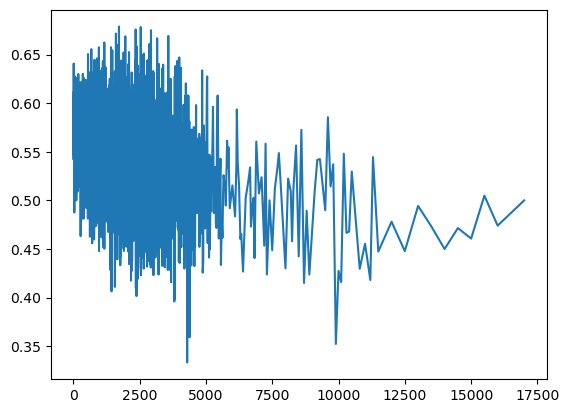

In [17]:
plt.plot(x_revol,y_revol)
plt.show()

# 데이터 클렌징 종합

In [ ]:
sec_app_mort_acc
sec_app_open_acc
sec_app_revol_util
sec_app_open_act_il
sec_app_num_rev_accts
sec_app_chargeoff_within_12_mths
sec_app_collections_12_mths_ex_med
hardship_flag
hardship_type
hardship_reason
hardship_status
deferral_term
hardship_amount
hardship_start_date
hardship_end_date
payment_plan_start_date
hardship_length
hardship_dpd
hardship_loan_status
orig_projected_additional_accrued_interest
hardship_payoff_balance_amount
hardship_last_payment_amount
debt_settlement_flag

In [371]:
temp_data.dtypes

sec_app_mort_acc                              float64
sec_app_open_acc                              float64
sec_app_revol_util                            float64
sec_app_open_act_il                           float64
sec_app_num_rev_accts                         float64
sec_app_chargeoff_within_12_mths              float64
sec_app_collections_12_mths_ex_med            float64
hardship_flag                                  object
hardship_type                                  object
hardship_reason                                object
hardship_status                                object
deferral_term                                 float64
hardship_amount                               float64
hardship_start_date                            object
hardship_end_date                              object
payment_plan_start_date                        object
hardship_length                               float64
hardship_dpd                                  float64
hardship_loan_status        

In [244]:
# 오브젝트타입 총 9 컬럼(원핫4, 라벨2, 날짜3)
# 원핫 엔코딩(4 컬럼)
def onehot(x):
	one = OneHotEncoder()
	temp_data = x.select_dtypes(include='object')
	temp_final = pd.DataFrame()

	for col in temp_data.columns:
		one.fit(temp_data[col].values.reshape(-1,1))

		col_df = pd.DataFrame(one.transform(temp_data[col].values.reshape(-1,1)).toarray().astype(int), columns=one.get_feature_names_out([col]))
		temp_final = pd.concat([temp_final, col_df], axis=1)
	return temp_final

# hardship_status 랑 hardship_loan_status는 조금 애매한데 라벨인코딩으로 함
onehot_list='''
hardship_flag
hardship_type
hardship_reason
debt_settlement_flag
'''
onehot_list=onehot_list.strip().split('\n')
onehot_data=temp_data[onehot_list]
temp_one=onehot(onehot_data)
 

# 열 삭제
columns_to_drop = ['hardship_flag', 'hardship_type', 'hardship_reason', 'debt_settlement_flag']
temp_data.drop(columns=columns_to_drop, inplace=True)

# 원핫 열추가
temp_data=pd.concat([temp_data, temp_one], axis=1)

In [245]:
# 라벨 인코딩(2 컬럼)
# 1. hardship_status
from sklearn.preprocessing import OrdinalEncoder

cate_order=['NA','BROKEN','ACTIVE','COMPLETE','COMPLETED']
encoder=OrdinalEncoder(categories=[cate_order])

temp_data['hardship_status'] = temp_data['hardship_status'].fillna('NA')
temp_data['hardship_status'] = encoder.fit_transform(temp_data[['hardship_status']])

# 결과 출력
# unique_values, counts = np.unique(df2, return_counts=True)
# for value, count in zip(unique_values, counts):
#     print(f"Value {value}: {count} times")

# 2. hardship_loan_status
status_mapping = {
    'current': 3,
    'active': 3,
    'issued': 3,
    'pipeline': 3,
    'in grace period': 2,
    'grace_current': 2,
    'late (16-30 days)': 2,
    'late (31-120 days)': 1,
    'delinquent': 1,
    'incollection': 1,
    'other': 0,
    'na': 0
}
temp_data['hardship_loan_status'].fillna('na',inplace=True)
temp_data['hardship_loan_status'] = temp_data['hardship_loan_status'].str.lower()
temp_data['hardship_loan_status'] = temp_data['hardship_loan_status'].map(status_mapping)

In [246]:
# 날짜 변환(3 컬럼)
temp_data['hardship_start_date']=pd.to_datetime(temp_data['hardship_start_date'], format='%b-%Y').dt.to_period('M')
temp_data['hardship_end_date']=pd.to_datetime(temp_data['hardship_end_date'], format='%b-%Y').dt.to_period('M')
temp_data['payment_plan_start_date']=pd.to_datetime(temp_data['payment_plan_start_date'], format='%b-%Y').dt.to_period('M')

# na 처리 코드

In [5]:
mths1_med=temp_data['mths_since_recent_bc_dlq'].median()
mths2_med=temp_data['mths_since_recent_revol_delinq'].median()

33.0

In [29]:
temp_na=temp_data.copy()

In [30]:
temp_na['mths_since_recent_bc_dlq'].fillna(mths1_med, inplace=True)
temp_na['mths_since_recent_revol_delinq'].fillna(mths2_med, inplace=True)

In [31]:
temp_na['revol_util'].fillna(0, inplace=True)
temp_na['bc_open_to_buy'].fillna(0, inplace=True)

In [32]:
temp_na['num_sats'].fillna(temp_na['open_acc'], inplace=True)

In [ ]:
# 5개 컬럼 전부 결측치 대체 방법 확정 x, 내일 공유 예정
mths1_med=temp_data['mths_since_recent_bc_dlq'].median()
mths2_med=temp_data['mths_since_recent_revol_delinq'].median()
temp_data['mths_since_recent_bc_dlq'].fillna(mths1_med, inplace=True)
temp_data['mths_since_recent_revol_delinq'].fillna(mths2_med, inplace=True)

temp_data['revol_util'].fillna(0, inplace=True)
temp_data['bc_open_to_buy'].fillna(0, inplace=True)

temp_data['num_sats'].fillna(temp_data['open_acc'], inplace=True)